# End-to-End MLflow Experiment Tracking and Model Lifecycle

**Dataset:** Iris (sklearn.datasets)  
**Models:** Logistic Regression vs Random Forest Classifier  
**Tasks Covered:** Experiment Tracking · Parameter/Metric Logging · Artifact Logging · Model Logging · Payload Validation · Model Registration · Run Comparison

## Section 1 – Install and Import Required Libraries

In [5]:
# Install dependencies using the active .venv kernel
import sys
import subprocess
from pathlib import Path

project_venv = (Path.cwd() / ".venv").resolve()
active_prefix = Path(sys.prefix).resolve()

if active_prefix != project_venv:
    raise RuntimeError("Select the '.venv' notebook kernel before running this cell.")

packages = ["mlflow", "scikit-learn", "matplotlib", "seaborn", "pandas", "numpy", "ipykernel"]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", *packages])

Current notebook Python: e:\assingment\.venv\Scripts\python.exe
All packages installed in e:/assingment/.venv successfully.


In [ ]:
# Core imports
import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, classification_report)

Importing from Python: e:\assingment\.venv\Scripts\python.exe
MLflow version : 3.10.1
All imports successful.


## Section 2 – Load and Prepare Dataset

In [7]:
# Load Iris dataset
iris = load_iris()
X, y = iris.data, iris.target

print("Dataset : Iris")
print(f"Shape   : {X.shape}  (samples × features)")
print(f"Features: {iris.feature_names}")
print(f"Classes : {list(iris.target_names)}")

# Train / test split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain samples : {X_train.shape[0]}")
print(f"Test  samples : {X_test.shape[0]}")

EXPECTED_FEATURES = X_train.shape[1]   # used in payload validation

Dataset : Iris
Shape   : (150, 4)  (samples × features)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Train samples : 120
Test  samples : 30


## Task 1 – Create MLflow Experiment and Start a Run

In [ ]:
# Use a portable local tracking database in the project root
mlflow.set_tracking_uri("sqlite:///mlflow.db")

EXPERIMENT_NAME = "Iris_Classification_Experiment"

# Set (or create) the experiment
mlflow.set_experiment(EXPERIMENT_NAME)
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

print(f"Experiment Name : {experiment.name}")
print(f"Experiment ID   : {experiment.experiment_id}")

# Parent run
parent_run = mlflow.start_run(run_name="Parent_Run")
PARENT_RUN_ID = parent_run.info.run_id
print(f"Run ID          : {PARENT_RUN_ID}")
mlflow.end_run()

Experiment Name : Iris_Classification_Experiment
Experiment ID   : 1
Artifact Store  : file:///e:/assingment/mlruns/1

Parent Run ID   : 813e6d8809c94873a63d10d4925cb3b9


## Task 2 – Train Two ML Models

In [9]:
# ── Model 1 : Logistic Regression ────────────────────────────────────────────
lr_params = {"C": 1.0, "solver": "lbfgs", "max_iter": 200}
lr_model   = LogisticRegression(**lr_params, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("=" * 50)
print("Logistic Regression – Classification Report")
print("=" * 50)
print(classification_report(y_test, lr_preds, target_names=iris.target_names))

# ── Model 2 : Random Forest ───────────────────────────────────────────────────
rf_params = {"n_estimators": 100, "max_depth": 5, "random_state": 42}
rf_model   = RandomForestClassifier(**rf_params)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("=" * 50)
print("Random Forest – Classification Report")
print("=" * 50)
print(classification_report(y_test, rf_preds, target_names=iris.target_names))

Logistic Regression – Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Random Forest – Classification Report
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Task 3 – Log Parameters and Metrics  
## Task 4 – Artifact Logging (Confusion Matrix + Performance Comparison)  
## Task 5 – Model Logging with MLflow

In [10]:
import os, tempfile

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Return a seaborn confusion-matrix figure."""
    cm  = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label",      fontsize=12)
    ax.set_title(f"Confusion Matrix – {model_name}", fontsize=13)
    plt.tight_layout()
    return fig


def log_model_run(run_name, model, params, preds, model_artifact_path):
    """
    Opens an MLflow run and logs params, metrics, artifacts, and the model.
    Returns (run_id, metrics_dict).
    """
    y_true    = y_test
    accuracy  = accuracy_score(y_true, preds)
    f1        = f1_score(y_true, preds, average="weighted")
    precision = precision_score(y_true, preds, average="weighted")
    recall    = recall_score(y_true, preds, average="weighted")

    with mlflow.start_run(run_name=run_name) as run:
        run_id = run.info.run_id

        # ── Task 3 : log parameters ──────────────────────────────────────────
        for k, v in params.items():
            mlflow.log_param(k, v)

        # ── Task 3 : log metrics ─────────────────────────────────────────────
        mlflow.log_metric("accuracy",  round(accuracy,  4))
        mlflow.log_metric("f1_score",  round(f1,        4))
        mlflow.log_metric("precision", round(precision, 4))
        mlflow.log_metric("recall",    round(recall,    4))

        # ── Task 4 : confusion matrix artifact ───────────────────────────────
        cm_fig  = plot_confusion_matrix(y_true, preds, run_name, iris.target_names)
        cm_path = os.path.join(tempfile.gettempdir(), f"confusion_matrix_{run_name}.png")
        cm_fig.savefig(cm_path, dpi=150)
        plt.close(cm_fig)
        mlflow.log_artifact(cm_path, artifact_path="plots")

        # ── Task 5 : log model ────────────────────────────────────────────────
        mlflow.sklearn.log_model(model, artifact_path=model_artifact_path)

        print(f"[{run_name}]  Run ID  : {run_id}")
        print(f"  Accuracy  : {accuracy:.4f}")
        print(f"  F1 Score  : {f1:.4f}")
        print(f"  Precision : {precision:.4f}")
        print(f"  Recall    : {recall:.4f}\n")

    return run_id, {"accuracy": accuracy, "f1_score": f1,
                    "precision": precision, "recall": recall}


# ── Run Logistic Regression ───────────────────────────────────────────────────
lr_run_id, lr_metrics = log_model_run(
    run_name="Logistic_Regression",
    model=lr_model,
    params={"C": lr_params["C"],
            "solver": lr_params["solver"],
            "max_iter": lr_params["max_iter"]},
    preds=lr_preds,
    model_artifact_path="logistic_regression_model"
)

# ── Run Random Forest ─────────────────────────────────────────────────────────
rf_run_id, rf_metrics = log_model_run(
    run_name="Random_Forest",
    model=rf_model,
    params={"n_estimators": rf_params["n_estimators"],
            "max_depth"   : rf_params["max_depth"],
            "random_state": rf_params["random_state"]},
    preds=rf_preds,
    model_artifact_path="random_forest_model"
)

2026/03/13 12:51:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 12:51:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Logistic_Regression]  Run ID  : 4ce6d378fd8f4abf9c2ca827a5af839d
  Accuracy  : 0.9667
  F1 Score  : 0.9666
  Precision : 0.9697
  Recall    : 0.9667



2026/03/13 12:51:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/13 12:51:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[Random_Forest]  Run ID  : 3cec21e32db34ba1b1bf8a18d0158eda
  Accuracy  : 0.9333
  F1 Score  : 0.9333
  Precision : 0.9333
  Recall    : 0.9333



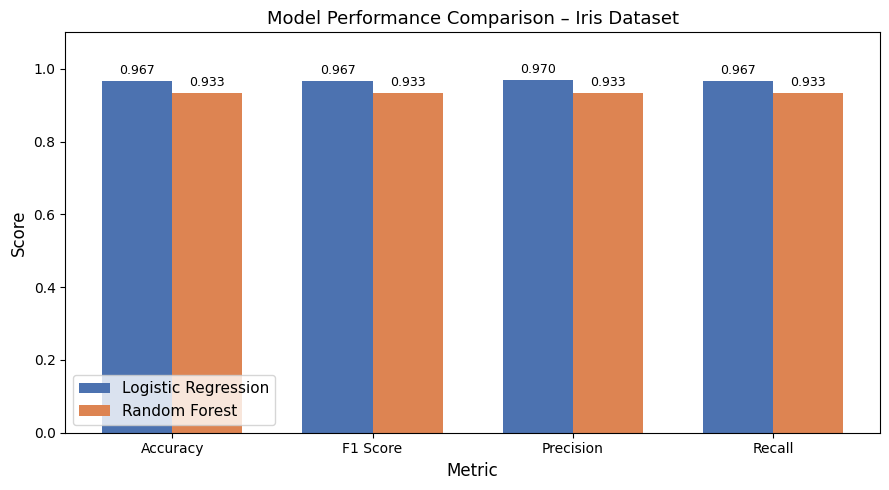

Performance comparison plot logged to both runs.


In [11]:
# ── Task 4 : Performance Comparison Plot (logged as artifact to BOTH runs) ────
models_names = ["Logistic Regression", "Random Forest"]
metric_names = ["accuracy", "f1_score", "precision", "recall"]
lr_vals = [lr_metrics[m] for m in metric_names]
rf_vals = [rf_metrics[m] for m in metric_names]

x     = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, lr_vals, width, label="Logistic Regression", color="#4C72B0")
bars2 = ax.bar(x + width/2, rf_vals, width, label="Random Forest",       color="#DD8452")

ax.set_xlabel("Metric",     fontsize=12)
ax.set_ylabel("Score",      fontsize=12)
ax.set_title("Model Performance Comparison – Iris Dataset", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metric_names])
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

# Save and log to both runs
perf_path = os.path.join(tempfile.gettempdir(), "performance_comparison.png")
fig.savefig(perf_path, dpi=150)
plt.close(fig)

for run_id in [lr_run_id, rf_run_id]:
    with mlflow.start_run(run_id=run_id):
        mlflow.log_artifact(perf_path, artifact_path="plots")

print("Performance comparison plot logged to both runs.")

## Task 6 – Payload Validation for Inference

In [12]:
def validate_payload(data: np.ndarray) -> None:
    """
    Validates inference payload before prediction.

    Checks:
    1. data is a 2-D numpy array.
    2. Number of features matches training data.
    3. No missing / NaN values.
    4. All values are numeric.
    """
    if not isinstance(data, np.ndarray):
        raise TypeError(f"Expected numpy.ndarray, got {type(data).__name__}.")

    if data.ndim != 2:
        raise ValueError(f"Input must be 2-D (samples × features); got shape {data.shape}.")

    if data.shape[1] != EXPECTED_FEATURES:
        raise ValueError(
            f"Expected {EXPECTED_FEATURES} features, got {data.shape[1]}."
        )

    if np.any(np.isnan(data)):
        raise ValueError("Payload contains NaN values. Remove missing data before inference.")

    if not np.issubdtype(data.dtype, np.number):
        raise TypeError(f"All features must be numeric; got dtype '{data.dtype}'.")

    print(f"Payload validation PASSED — shape {data.shape}, dtype {data.dtype}.")


# ── Valid payload ──────────────────────────────────────────────────────────────
sample_payload = np.array([[5.1, 3.5, 1.4, 0.2],    # expected: setosa
                            [6.7, 3.0, 5.2, 2.3]])   # expected: virginica

validate_payload(sample_payload)

lr_prediction = lr_model.predict(sample_payload)
rf_prediction = rf_model.predict(sample_payload)

label_map = {i: name for i, name in enumerate(iris.target_names)}

print("\nSample Payload:")
print(pd.DataFrame(sample_payload, columns=iris.feature_names).to_string(index=False))
print("\nLogistic Regression prediction :",
      [label_map[p] for p in lr_prediction])
print("Random Forest     prediction :",
      [label_map[p] for p in rf_prediction])

# ── Invalid payload demo ───────────────────────────────────────────────────────
print("\n--- Invalid payload demo ---")
try:
    bad_payload = np.array([[5.1, 3.5, 1.4]])   # only 3 features
    validate_payload(bad_payload)
except ValueError as e:
    print(f"Caught expected error: {e}")

try:
    nan_payload = np.array([[5.1, np.nan, 1.4, 0.2]])
    validate_payload(nan_payload)
except ValueError as e:
    print(f"Caught expected error: {e}")

Payload validation PASSED — shape (2, 4), dtype float64.

Sample Payload:
 sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
               5.1               3.5                1.4               0.2
               6.7               3.0                5.2               2.3

Logistic Regression prediction : [np.str_('setosa'), np.str_('virginica')]
Random Forest     prediction : [np.str_('setosa'), np.str_('virginica')]

--- Invalid payload demo ---
Caught expected error: Expected 4 features, got 3.
Caught expected error: Payload contains NaN values. Remove missing data before inference.


## Task 7 – Model Registration in MLflow Model Registry

In [13]:
import time

REGISTERED_MODEL_NAME = "MLflow_Iris_Classifier"

# Determine the best model by accuracy
if lr_metrics["accuracy"] >= rf_metrics["accuracy"]:
    best_run_id    = lr_run_id
    best_model_uri = f"runs:/{lr_run_id}/logistic_regression_model"
    best_model_name = "Logistic Regression"
else:
    best_run_id    = rf_run_id
    best_model_uri = f"runs:/{rf_run_id}/random_forest_model"
    best_model_name = "Random Forest"

print(f"Registering best model: {best_model_name}")
print(f"Model URI             : {best_model_uri}")

# Register model (may take a moment to index artifacts)
result = mlflow.register_model(
    model_uri=best_model_uri,
    name=REGISTERED_MODEL_NAME
)

print(f"\nRegistered Model Name : {result.name}")
print(f"Version               : {result.version}")
print(f"Status                : {result.status}")

Registering best model: Logistic Regression
Model URI             : runs:/4ce6d378fd8f4abf9c2ca827a5af839d/logistic_regression_model


Successfully registered model 'MLflow_Iris_Classifier'.
2026/03/13 12:51:38 WARNING mlflow.tracking._model_registry.fluent: Run with id 4ce6d378fd8f4abf9c2ca827a5af839d has no artifacts at artifact path 'logistic_regression_model', registering model based on models:/m-a5423ecb6ec942a39f79a06312aaf63a instead
Created version '1' of model 'MLflow_Iris_Classifier'.



Registered Model Name : MLflow_Iris_Classifier
Version               : 1
Status                : READY


## Task 8 – Compare Model Runs

In [14]:
client = MlflowClient()

def get_run_summary(run_id: str, label: str) -> dict:
    run  = client.get_run(run_id)
    d    = {"Model": label}
    d.update(run.data.params)
    d.update({k: round(v, 4) for k, v in run.data.metrics.items()})
    return d

rows = [
    get_run_summary(lr_run_id, "Logistic Regression"),
    get_run_summary(rf_run_id, "Random Forest"),
]

comparison_df = pd.DataFrame(rows).set_index("Model")
print("=" * 70)
print("           Model Run Comparison")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)

# ── Answer the comparison questions ──────────────────────────────────────────
lr_acc = lr_metrics["accuracy"]
rf_acc = rf_metrics["accuracy"]

if lr_acc > rf_acc:
    winner = "Logistic Regression"
    winner_acc = lr_acc
elif rf_acc > lr_acc:
    winner = "Random Forest"
    winner_acc = rf_acc
else:
    winner = "Tie"
    winner_acc = lr_acc

print(f"\nQ1 – Which model performed better?")
print(f"     --> {winner}  (Accuracy: {winner_acc:.4f})")
print(f"\nQ2 – What metric determined the best model?")
print(f"     --> Accuracy (primary) and F1 Score (secondary / weighted avg)")

           Model Run Comparison
                       C solver max_iter  accuracy  f1_score  precision  recall n_estimators max_depth random_state
Model                                                                                                              
Logistic Regression  1.0  lbfgs      200    0.9667    0.9666     0.9697  0.9667          NaN       NaN          NaN
Random Forest        NaN    NaN      NaN    0.9333    0.9333     0.9333  0.9333          100         5           42

Q1 – Which model performed better?
     --> Logistic Regression  (Accuracy: 0.9667)

Q2 – What metric determined the best model?
     --> Accuracy (primary) and F1 Score (secondary / weighted avg)


---
## How to View the MLflow UI

From the project root, run:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000
```

Then open **http://127.0.0.1:5000** in your browser.

If port 5000 is busy, use another port:

```bash
mlflow ui --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5001
```